In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [19]:
nav_df = pd.read_csv("../data/processed/nav_history.csv")

nav_df.head()

,scheme_code,date,nav
0,120001,2025-01-01,87.44
1,120001,2025-01-02,32.52
2,120001,2025-01-03,13.50
3,120001,2025-01-04,37.29
4,120001,2025-01-05,58.34


In [20]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

nav_df = nav_df.sort_values(['scheme_code', 'date'])

In [21]:
nav_df['daily_return'] = (
    nav_df.groupby('scheme_code')['nav']
    .pct_change()
)

nav_df.head()

,scheme_code,date,nav,daily_return
0,120001,2025-01-01,87.44,NaN
1,120001,2025-01-02,32.52,-0.628088
2,120001,2025-01-03,13.50,-0.584871
3,120001,2025-01-04,37.29,1.762222
4,120001,2025-01-05,58.34,0.564495


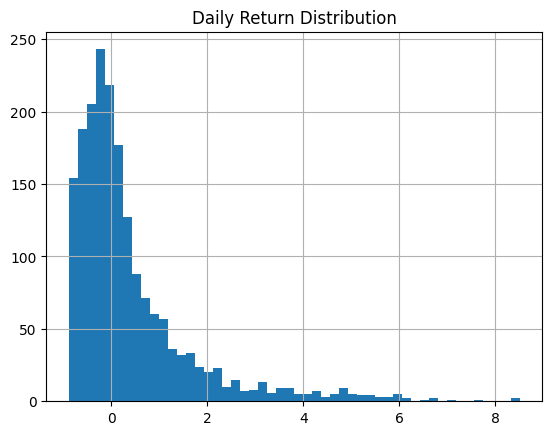

In [22]:
nav_df['daily_return'].hist(bins=50)

plt.title("Daily Return Distribution")

plt.show()

In [23]:
cagr_list = []

for scheme in nav_df['scheme_code'].unique():

    temp = nav_df[nav_df['scheme_code'] == scheme]

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    years = 1

    cagr = ((end_nav / start_nav) ** (1/years)) - 1

    cagr_list.append([scheme, cagr])

cagr_df = pd.DataFrame(cagr_list, columns=['scheme_code', 'CAGR'])

cagr_df.head()

,scheme_code,CAGR
0,120001,-0.475183
1,120002,-0.708486
2,120003,-0.813259
3,120004,-0.631316
4,120005,1.087001


In [24]:
RF = 0.065

sharpe_list = []

for scheme in nav_df['scheme_code'].unique():

    temp = nav_df[nav_df['scheme_code'] == scheme]

    mean_return = temp['daily_return'].mean()

    std_return = temp['daily_return'].std()

    sharpe = (
        (mean_return - RF/252)
        / std_return
    ) * np.sqrt(252)

    sharpe_list.append([scheme, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=['scheme_code', 'Sharpe_Ratio']
)

sharpe_df.head()

,scheme_code,Sharpe_Ratio
0,120001,5.493233
1,120002,4.102599
2,120003,4.507201
3,120004,1.823379
4,120005,5.607355


In [25]:
sortino_list = []

for scheme in nav_df['scheme_code'].unique():

    temp = nav_df[nav_df['scheme_code'] == scheme]

    negative_returns = temp[temp['daily_return'] < 0]['daily_return']

    downside_std = negative_returns.std()

    mean_return = temp['daily_return'].mean()

    sortino = (
        (mean_return - RF/252)
        / downside_std
    ) * np.sqrt(252)

    sortino_list.append([scheme, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=['scheme_code', 'Sortino_Ratio']
)

sortino_df.head()

,scheme_code,Sortino_Ratio
0,120001,27.370234
1,120002,26.622644
2,120003,36.619794
3,120004,6.402756
4,120005,29.916065


In [26]:
benchmark_return = np.random.normal(0.001, 0.02, len(nav_df))

alpha_beta = []

for scheme in nav_df['scheme_code'].unique():

    temp = nav_df[nav_df['scheme_code'] == scheme]

    returns = temp['daily_return'].dropna()

    benchmark = benchmark_return[:len(returns)]

    beta, alpha, r, p, se = linregress(
        benchmark,
        returns
    )

    annual_alpha = alpha * 252

    alpha_beta.append([
        scheme,
        annual_alpha,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=['scheme_code', 'Alpha', 'Beta']
)

alpha_beta_df.head()

,scheme_code,Alpha,Beta
0,120001,105.763602,-0.562908
1,120002,103.196932,-24.920157
2,120003,118.479921,49.173658
3,120004,24.463615,-7.964557
4,120005,96.820782,16.810456


In [27]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [28]:
drawdown_list = []

for scheme in nav_df['scheme_code'].unique():

    temp = nav_df[nav_df['scheme_code'] == scheme]

    running_max = temp['nav'].cummax()

    drawdown = (
        temp['nav'] / running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_list.append([
        scheme,
        max_dd
    ])

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=['scheme_code', 'Max_Drawdown']
)

drawdown_df.head()

,scheme_code,Max_Drawdown
0,120001,-0.859140
1,120002,-0.848173
2,120003,-0.884067
3,120004,-0.772900
4,120005,-0.856522


In [29]:
scorecard = cagr_df.merge(
    sharpe_df,
    on='scheme_code'
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on='scheme_code'
)

scorecard = scorecard.merge(
    drawdown_df,
    on='scheme_code'
)

scorecard['Score'] = (
    scorecard['CAGR'].rank(pct=True) * 30 +
    scorecard['Sharpe_Ratio'].rank(pct=True) * 25 +
    scorecard['Alpha'].rank(pct=True) * 20 +
    scorecard['Max_Drawdown'].rank(pct=True) * 10
)

scorecard.head()

,scheme_code,CAGR,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,Score
0,120001,-0.475183,5.493233,105.763602,-0.562908,-0.859140,41.05
1,120002,-0.708486,4.102599,103.196932,-24.920157,-0.848173,25.55
2,120003,-0.813259,4.507201,118.479921,49.173658,-0.884067,24.50
3,120004,-0.631316,1.823379,24.463615,-7.964557,-0.772900,16.25
4,120005,1.087001,5.607355,96.820782,16.810456,-0.856522,56.60


In [30]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

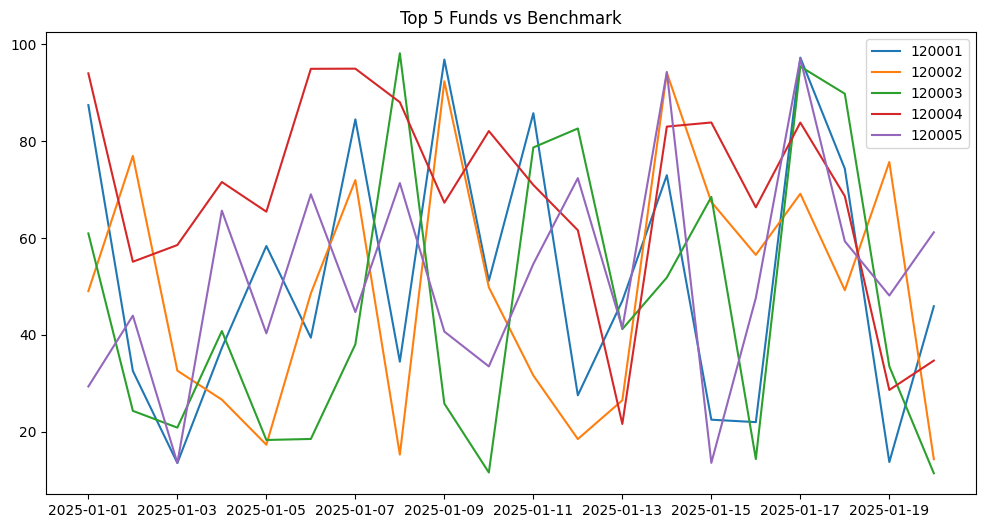

In [31]:
top_funds = nav_df['scheme_code'].unique()[:5]

plt.figure(figsize=(12,6))

for scheme in top_funds:

    temp = nav_df[
        nav_df['scheme_code'] == scheme
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=str(scheme)
    )

plt.title("Top 5 Funds vs Benchmark")

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()

In [32]:
tracking_error_list = []

for scheme in nav_df['scheme_code'].unique():

    temp = nav_df[
        nav_df['scheme_code'] == scheme
    ]

    tracking_error = (
        np.std(
            temp['daily_return'].dropna()
        )
    ) * np.sqrt(252)

    tracking_error_list.append([
        scheme,
        tracking_error
    ])

tracking_error_df = pd.DataFrame(
    tracking_error_list,
    columns=['scheme_code', 'Tracking_Error']
)

tracking_error_df.head()

,scheme_code,Tracking_Error
0,120001,18.686397
1,120002,21.977932
2,120003,30.043603
3,120004,11.233674
4,120005,18.023765


In [33]:
tracking_error_list = []

for scheme in nav_df['scheme_code'].unique():

    temp = nav_df[
        nav_df['scheme_code'] == scheme
    ]

    tracking_error = (
        np.std(
            temp['daily_return'].dropna()
        )
    ) * np.sqrt(252)

    tracking_error_list.append([
        scheme,
        tracking_error
    ])

tracking_error_df = pd.DataFrame(
    tracking_error_list,
    columns=['scheme_code', 'Tracking_Error']
)

tracking_error_df.head()

,scheme_code,Tracking_Error
0,120001,18.686397
1,120002,21.977932
2,120003,30.043603
3,120004,11.233674
4,120005,18.023765
